# Clasical ML model selection - Baseline features

Just like in 06_classification_baseline.ipynb, I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

Run with all features...

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import xgboost as xgb

import joblib
import json
from datetime import datetime
import os

import core.constants as c
from core.processing import ResultsModel, ResultModel
from core.utils import extract_subject_id
from core.evaluation import model_test_summary, pick_threshold
from core.model_selection import split_train_test_set
from core.evaluation import SklearnAPIPredictor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
SAVE_MODEL = True
MODEL_NAME = "baseline_strict_out"

In [ ]:
X_train_all = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE_2, index_col=0)
y_train_all = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE_2, index_col=0)

X_train, X_val, y_train, y_val = split_train_test_set(
    X_train_all, y_train_all, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X_train_all.index.to_series())
)

print("="*30)
print("Train")
print("="*30)
print(f"X Dataset shape: {X_train.shape}")
print(f"X Columns: {list(X_train.columns)}")
display(X_train.head())

print(f"Y Dataset shape: {y_train.shape}")
print(f"Y Columns: {list(y_train.columns)}")
display(y_train.head())

# Class imbalance
print(f"Class distribution: {y_train['is_injured'].value_counts()}")
print(f"Class distribution: {y_train['is_injured'].value_counts(normalize=True)}")


print("\n" + "="*30)
print("Validation")
print("="*30)
print(f"X Dataset shape: {X_val.shape}")
print(f"X Columns: {list(X_val.columns)}")
display(X_val.head())

print(f"Y Dataset shape: {y_val.shape}")
print(f"Y Columns: {list(y_val.columns)}")
display(y_val.head())

# Class imbalance
print(f"Class distribution: {y_val['is_injured'].value_counts()}")
print(f"Class distribution: {y_val['is_injured'].value_counts(normalize=True)}")


Train
X Dataset shape: (1142, 84)
X Columns: ['age', 'height', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_diff_ankle_df_peak_angle', 'dom_leg_ankle_eve_excursion', 'dom_leg_diff_ankle_eve_excursion', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_peak_vel', 'dom_leg_ankle_eve_percent_stance', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_angle', 'dom_leg_diff_ankle_rot_peak_angle', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_diff_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_foot_prog_angle', 'dom_leg_diff_foot_prog_angle', 'dom_leg_hip_abd_peak_vel', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_hip_add_excursion', 'dom_leg_diff_hip_add_excursion', 'dom_leg_hip_add_peak_angle', 'dom_leg_diff_hip_add_peak_angle', 'dom_leg_hip_add_peak_vel', 'dom_leg_diff_hip_add_peak_vel', 'dom_leg_hip_ex

,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_female,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.716796,-0.040618,-0.634605,1.018751,0.682578,1.087067,0.395798,1.485201,0.489915,1.350380,...,-0.851780,-0.050677,0.567631,-0.321703,0.185710,1.168531,0.534832,0.340909,1.0,0.0
100002_20110601T140505,-0.099721,0.113783,0.029859,1.087823,-0.797742,1.421178,1.284185,-0.951915,-0.165420,0.786429,...,-0.321937,-0.050677,-0.343351,2.454867,0.439287,1.922466,-0.059706,-1.060430,0.0,1.0
100003_20110601T095930,1.043402,1.503392,1.244226,1.311845,0.452929,0.224250,0.926212,-0.657482,-0.043043,-0.070744,...,-0.851780,-0.050677,-0.950672,-1.496405,0.439287,-0.150857,-0.654105,-0.791567,0.0,1.0
100006_20110209T104505,0.226886,0.510814,0.824162,0.451787,0.175701,0.407446,-1.025267,0.830074,1.841848,-0.252981,...,0.728535,-0.050677,-1.051892,-0.428494,-0.067866,-0.339341,-0.508458,-0.125468,0.0,1.0
100007_20110209T135403,-0.263025,-1.143483,1.053288,0.436480,-0.231588,0.408751,1.672314,1.158034,0.213426,0.557343,...,0.363477,-0.050677,0.061530,-0.962450,-1.208959,-1.093276,-0.012046,0.919826,1.0,0.0


Y Dataset shape: (1142, 1)
Y Columns: ['is_injured']


,is_injured
id,
100001_20110531T161051,True
100002_20110601T140505,True
100003_20110601T095930,True
100006_20110209T104505,True
100007_20110209T135403,True


Class distribution: is_injured
True     734
False    408
Name: count, dtype: int64
Class distribution: is_injured
True     0.642732
False    0.357268
Name: proportion, dtype: float64

Validation
X Dataset shape: (304, 84)
X Columns: ['age', 'height', 'weight', 'dom_leg_ankle_df_peak_angle', 'dom_leg_diff_ankle_df_peak_angle', 'dom_leg_ankle_eve_excursion', 'dom_leg_diff_ankle_eve_excursion', 'dom_leg_ankle_eve_peak_angle', 'dom_leg_diff_ankle_eve_peak_angle', 'dom_leg_ankle_eve_peak_vel', 'dom_leg_diff_ankle_eve_peak_vel', 'dom_leg_ankle_eve_percent_stance', 'dom_leg_diff_ankle_eve_percent_stance', 'dom_leg_ankle_rot_excursion', 'dom_leg_diff_ankle_rot_excursion', 'dom_leg_ankle_rot_peak_angle', 'dom_leg_diff_ankle_rot_peak_angle', 'dom_leg_ankle_rot_peak_vel', 'dom_leg_diff_ankle_rot_peak_vel', 'dom_leg_foot_ang_at_hs', 'dom_leg_diff_foot_ang_at_hs', 'dom_leg_foot_prog_angle', 'dom_leg_diff_foot_prog_angle', 'dom_leg_hip_abd_peak_vel', 'dom_leg_diff_hip_abd_peak_vel', 'dom_leg_hip_add

,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_female,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100004_20110203T120721,-0.263025,0.356413,-0.856093,0.997893,-0.631185,0.444125,-0.536713,0.969637,0.189217,-0.223080,...,-0.211613,-0.050677,-1.153113,-0.855658,0.312498,-1.470244,0.304484,0.965826,0.0,1.0
100004_20140929T102035,0.063582,0.290241,-0.703343,1.101426,-0.616447,-0.502962,-1.727133,-1.310800,-0.187125,-0.959901,...,0.013630,2.300819,-1.254333,-0.428494,-0.194654,-0.716308,-0.002127,1.316334,0.0,1.0
100010_20110303T120402,1.043402,-1.805201,-0.321467,0.242031,-0.709005,0.624250,1.233568,2.125846,1.718197,0.894989,...,-0.748619,-0.050677,0.871292,-1.176032,-0.067866,0.226111,-1.073726,-0.529031,1.0,0.0
100016_20110329T161600,1.533313,-0.481764,-0.168716,-0.169468,-1.517999,1.576695,0.083272,0.501629,1.295886,1.914249,...,-0.591112,-1.149093,0.061530,0.105462,0.375893,-0.150857,-0.066057,-0.150028,0.0,1.0
100018_20110331T120427,-1.242845,0.874759,-0.245091,1.559075,-0.276383,0.098330,-0.801374,-1.243934,-1.273188,-0.789382,...,-0.748619,-0.050677,-1.760434,-0.321703,0.819651,0.037627,0.726808,0.075355,0.0,1.0


Y Dataset shape: (304, 1)
Y Columns: ['is_injured']


,is_injured
id,
100004_20110203T120721,True
100004_20140929T102035,False
100010_20110303T120402,True
100016_20110329T161600,True
100018_20110331T120427,True


Class distribution: is_injured
True     193
False    111
Name: count, dtype: int64
Class distribution: is_injured
True     0.634868
False    0.365132
Name: proportion, dtype: float64


In [4]:
neg_pos_ratio = y_train['is_injured'].value_counts().iloc[0] / y_train['is_injured'].value_counts().iloc[1]
print(f"Negative to positive ratio: {neg_pos_ratio}")

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': np.logspace(-3, 3, 7),
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE,  class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5, 10, 16],
            'classifier__min_samples_leaf': [2, 5, 8],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', max_delta_step=1))
        ]),
        'param_grid': {
            'classifier__n_estimators': [100, 200, 500],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.005, 0.01, 0.1],
            'classifier__subsample': [0.8, 1.0],  # Add randomess for colinearity
            'classifier__colsample_bytree': [0.8, 1.0],
            'classifier__gamma': [0, 1, 5],
            'classifier__scale_pos_weight': [neg_pos_ratio]  # For class imbalance - See https://xgboost.readthedocs.io/en/stable/tutorials/param_tuning.html#handle-imbalanced-dataset
        }
    },
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear', 'poly'],
            'classifier__gamma': ['scale', 0.1, 0.01]
        }
    }
}

Negative to positive ratio: 1.7990196078431373


In [5]:
print("SHPAES")
print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_val: ", X_val.shape)
print("y_val: ", y_val.shape)

SHPAES
X_train:  (1142, 84)
y_train:  (1142, 1)
X_val:  (304, 84)
y_val:  (304, 1)


In [6]:
from sklearn.model_selection import StratifiedGroupKFold
import pickle
from pathlib import Path

# Train set for the best parameter model
X_train_all = pd.concat([X_train, X_val])
y_train_all = pd.concat([y_train, y_val])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
groups_train = extract_subject_id(X_train.index.to_series())

trained_models = {}
results = {}

folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
folder_path.mkdir(parents=True, exist_ok=True)

if SAVE_MODEL:
    for model_name, config in models_config.items():
        print('\n' + '='*30)
        print(f"Training {model_name}...")
        print('='*30)    
        grid_search = GridSearchCV(
            estimator=config['pipeline'],
            param_grid=config['param_grid'],
            cv = cv,
            scoring='roc_auc',
            n_jobs=-1,
            verbose=1,
        )

        # Hyperparameter tuning with train set
        grid_search.fit(X_train, y_train.values.ravel(), groups=groups_train)

        # Train best parameters model on full train+val
        best_model = grid_search.best_estimator_
        best_model.fit(X_train_all, y_train_all.values.ravel())

        # Find best threshold from validation set
        y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
        best_threshold, stats = pick_threshold(y_val, y_pred_proba_val, method="macro")  # Macro is good for imbalanced data
        print(f"Best threshold (val): {best_threshold}")


        # Save best results:
        trained_models[model_name] = best_model
        results[model_name] = {
            'best_threshold': best_threshold,
            'best_score': grid_search.best_score_,
            'best_params': grid_search.best_params_,
            'cv_results': grid_search.cv_results_,
        }
        
        print(f"Best CV Score: {grid_search.best_score_:.4f}")
        print(f"Best Parameters: {grid_search.best_params_}")
    with open(f"{folder_path}/trained_models.pkl", "wb") as f:
        pickle.dump(trained_models, f)
else:
    print("Loading results and trained models...")
    with open(f"{folder_path}/results.pkl", "rb") as f:
        results = pickle.load(f)
    
    with open(f"{folder_path}/trained_models.pkl", "rb") as f:
        trained_models = pickle.load(f)
    
    for model_name, model_results in results.items():
        print('\n' + '='*30)
        print(f"Model: {model_name}")
        print('='*30)
        print(f"Best threshold (val): {model_results['best_threshold']}")
        print(f"Best CV Score: {model_results['best_score']:.4f}")
        print(f"Best Parameters: {model_results['best_params']}")


Training Logistic Regression...
Fitting 5 folds for each of 14 candidates, totalling 70 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Best threshold (val): 0.43248102667532046
Best CV Score: 0.6824
Best Parameters: {'classifier__C': np.float64(0.1), 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Training Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best threshold (val): 0.6274598472657112
Best CV Score: 0.6793
Best Parameters: {'classifier__max_depth': 20, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 200}

Training XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best threshold (val): 0.6644829511642456
Best CV Score: 0.6777
Best Parameters: {'classifier__colsample_bytree': 1.0, 'classifier__gamma': 0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': np.float64(1.7990196078431373), 'classifier__subsample': 0.8}

Training SVM...
Fitting 5 folds for each of 27 candidates, to

X_test shape: (367, 84)
y_test shape: (367, 1)


Model: Logistic Regression
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6272
Test AUC-ROC : 0.5722
=== Threshold Dependent Metrics ===
=== Threshold: 0.43 ===
Test Accuracy : 0.6294
Test F1-Macro Score : 0.5977
Test Precision : 0.6789
Test Recall : 0.7455

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.68      0.75      0.71       224
 Not Injured       0.53      0.45      0.48       143

    accuracy                           0.63       367
   macro avg       0.60      0.60      0.60       367
weighted avg       0.62      0.63      0.62       367


Model: Random Forest
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6902
Test AUC-ROC : 0.6000
=== Threshold Dependent Metrics ===
=== Threshold: 0.63 ===
Test Accuracy : 0.5722
Test F1-Macro Score : 0.5665
Test Precision : 0.6811
Test Recall : 0.5625

=== CLASSIFICATION REPORT ===
 

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per


Model: XGBoost
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6464
Test AUC-ROC : 0.5703
=== Threshold Dependent Metrics ===
=== Threshold: 0.66 ===
Test Accuracy : 0.6185
Test F1-Macro Score : 0.5703
Test Precision : 0.6579
Test Recall : 0.7812

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.66      0.78      0.71       224
 Not Injured       0.51      0.36      0.43       143

    accuracy                           0.62       367
   macro avg       0.59      0.57      0.57       367
weighted avg       0.60      0.62      0.60       367


Model: SVM
MODEL EVALUATION RESULTS
=== Test Prevalence: 61.04 ===
Test AUC-PR : 0.6636
Test AUC-ROC : 0.6099
=== Threshold Dependent Metrics ===
=== Threshold: 0.42 ===
Test Accuracy : 0.6240
Test F1-Macro Score : 0.5544
Test Precision : 0.6493
Test Recall : 0.8348

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured    

<Figure size 640x480 with 0 Axes>

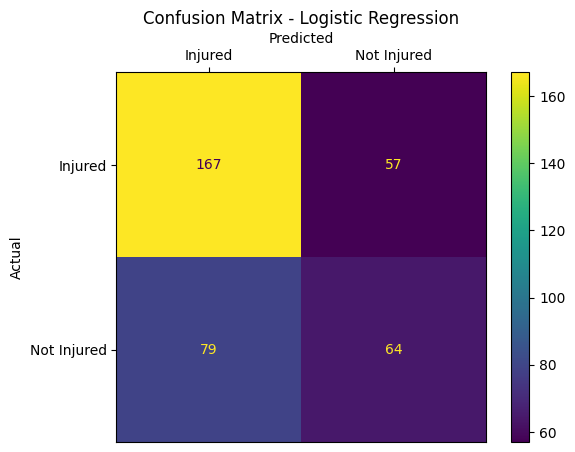

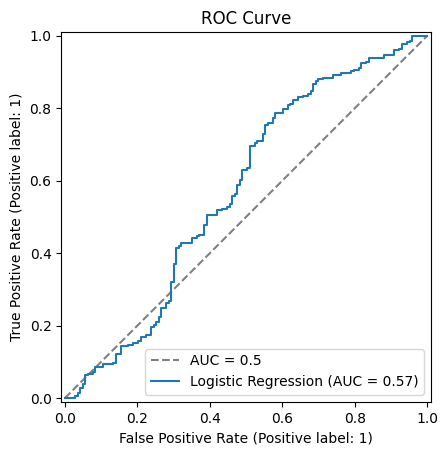

<Figure size 640x480 with 0 Axes>

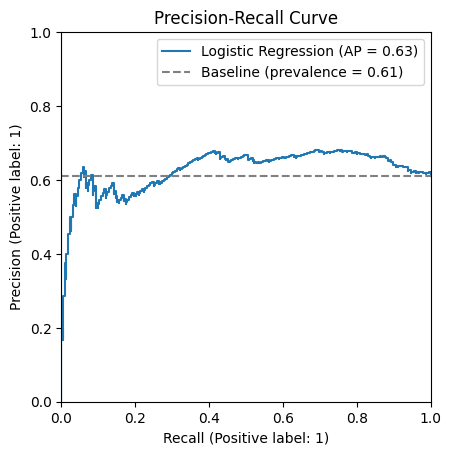

<Figure size 640x480 with 0 Axes>

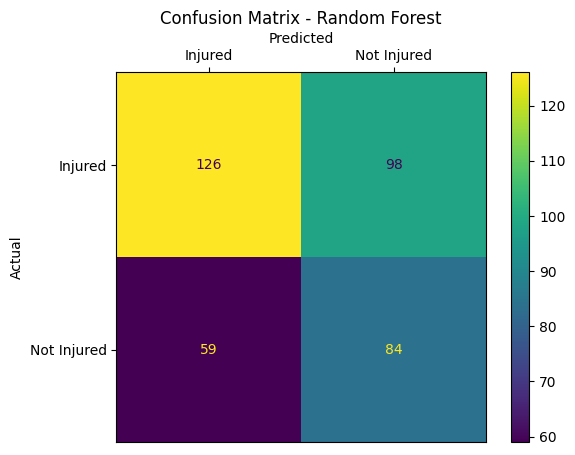

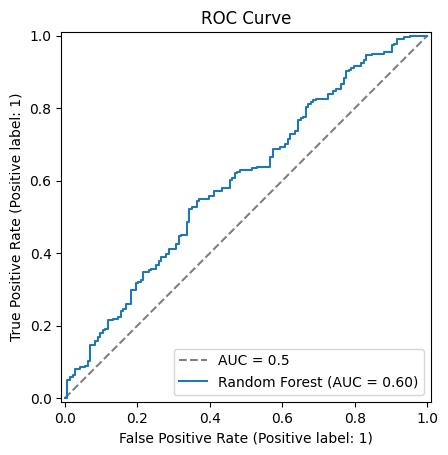

<Figure size 640x480 with 0 Axes>

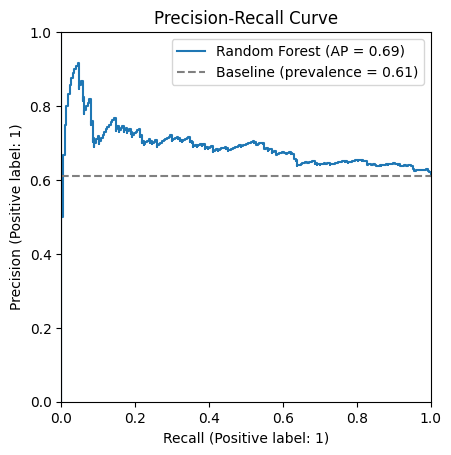

<Figure size 640x480 with 0 Axes>

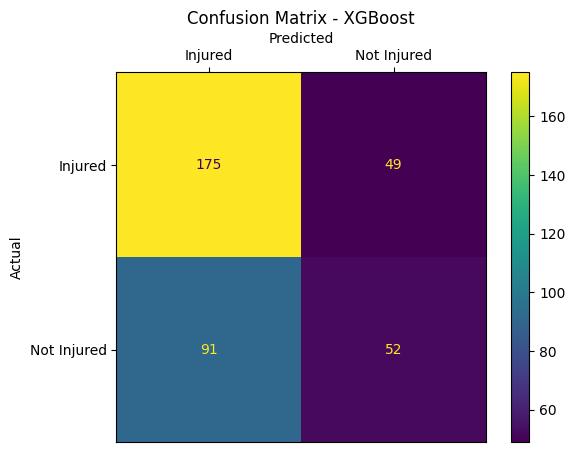

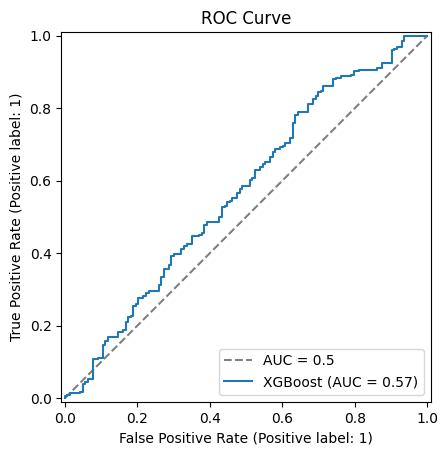

<Figure size 640x480 with 0 Axes>

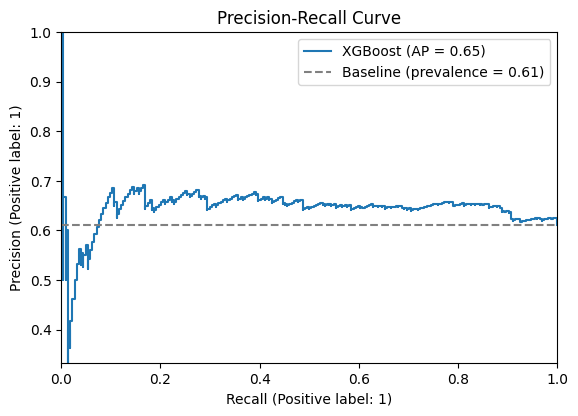

<Figure size 640x480 with 0 Axes>

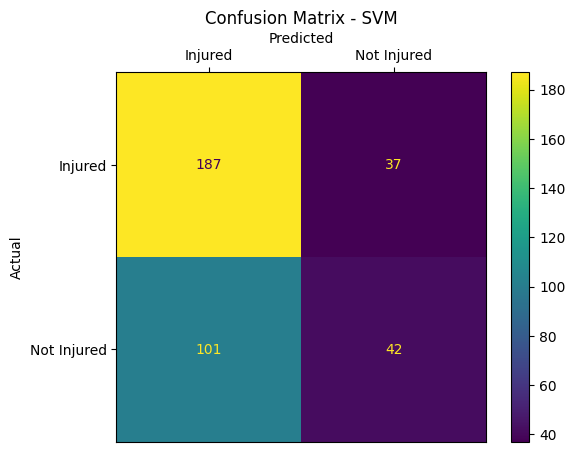

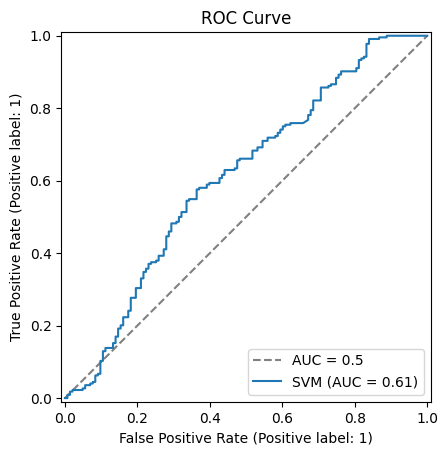

<Figure size 640x480 with 0 Axes>

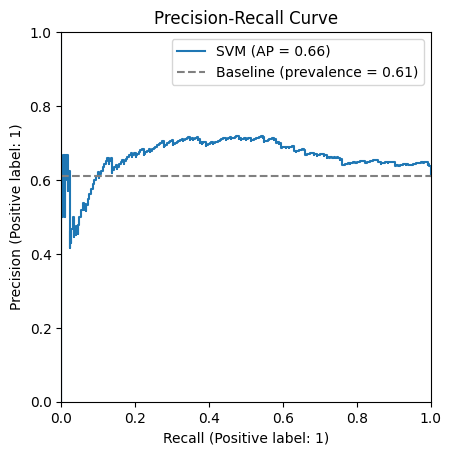

In [7]:
X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE_2, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE_2, index_col=0)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print()


for model_name, model in trained_models.items():
    print('\n' + '='*50)
    print(f"Model: {model_name}")
    best_threshold = results[model_name]['best_threshold']
    pred = SklearnAPIPredictor(model)
    test_summary = model_test_summary(model, X_test, y_test,
        threshold=best_threshold,
        predictor=pred,
        model_name=model_name,
        save_predictions=True,
    )
    
    results[model_name].update(test_summary)

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test PR AUC  Test Accuracy  \
3                  SVM        0.6099       0.6636         0.6240   
1        Random Forest        0.6000       0.6902         0.5722   
0  Logistic Regression        0.5722       0.6272         0.6294   
2              XGBoost        0.5703       0.6464         0.6185   

   Test Precision  Test Recall  Test F1-Score  Test Prevalence  Test Threshold  
3          0.6493       0.8348         0.5544           0.6104          0.4226  
1          0.6811       0.5625         0.5665           0.6104          0.6275  
0          0.6789       0.7455         0.5977           0.6104          0.4325  
2          0.6579       0.7812         0.5703           0.6104          0.6645  

Best performing model: SVM
Best Test ROC AUC Score: 0.6099


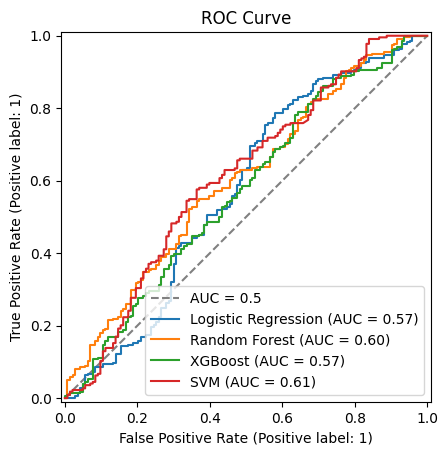

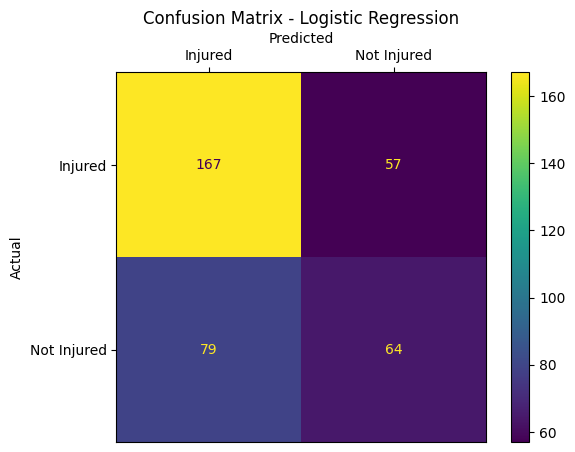

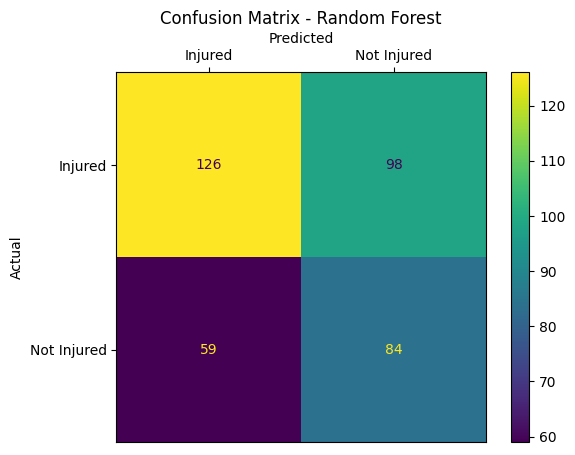

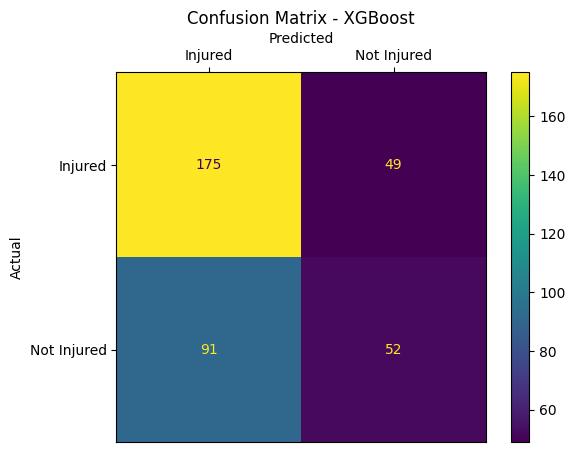

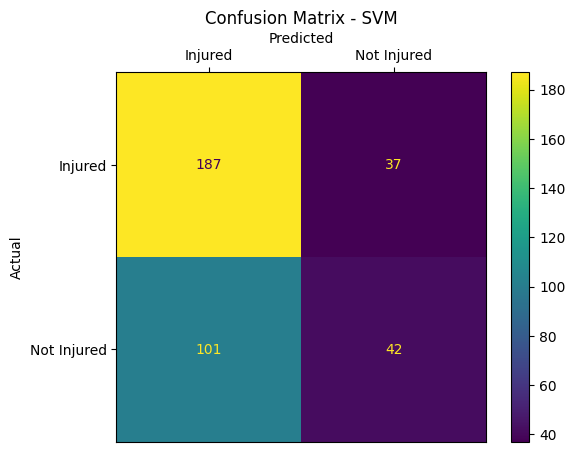

In [8]:
comparison_data = []
ax = plt.gca()

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='AUC = 0.5')

for model_name, result in results.items():
    comparison_data.append({
        'Model': model_name,
        'Test ROC AUC': result['auc_roc'],
        'Test PR AUC': result['auc_pr'],
        'Test Accuracy': result['accuracy'],
        'Test Precision': result['precision'],
        'Test Recall': result['recall'],
        'Test F1-Score': result['f1'],
        'Test Prevalence': result['prevalence'],
        'Test Threshold': result['threshold'],
    })
    roc_disp = RocCurveDisplay.from_predictions(
        y_test, 
        result['y_pred_proba'], 
        name=model_name,
        ax=ax,
    )
roc_disp.ax_.set_title('ROC Curve')

for model_name, result in results.items():
    class_labels = ['Injured', 'Not Injured']
    cm_disp = ConfusionMatrixDisplay.from_predictions(
        y_test, 
        result['y_pred'], 
        display_labels=class_labels,
        labels=[1, 0]
    )
    cm_disp.ax_.xaxis.set_label_position('top')
    cm_disp.ax_.xaxis.set_ticks_position('top')
    cm_disp.ax_.xaxis.set_label_text('Predicted')
    cm_disp.ax_.yaxis.set_label_text('Actual')
    cm_disp.ax_.set_title(f'Confusion Matrix - {model_name}')

PRIMARY_METRIC = 'Test ROC AUC'
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(PRIMARY_METRIC, ascending=False)

print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")

In [9]:
import pickle
from pathlib import Path

if SAVE_MODEL:
    folder_path = Path(f"{c.RICKD_MODELS_FOLDER}/{MODEL_NAME}")
    folder_path.mkdir(parents=True, exist_ok=True)

    with open(f"{folder_path}/results.pkl", "wb") as f:
        pickle.dump(results, f)
